In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [3]:
def plot_various_loads(file_path, metric, metric_label, x_labels, model_name, data_name, system_names, system_labels, num_prompts):
    df = pd.read_csv(file_path)
    df = df[df['model_name'] == model_name]
    df = df.groupby(['model_name', 'num_prompt', 'system_name']).mean().reset_index()
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 输出improvement
    for num_prompt in num_prompts:
        for i, system_name in enumerate(system_names):
            system_df = df[(df['num_prompt'] == num_prompt) & (df['system_name'] == system_name)]
            metric_value = list(system_df[metric].values)[0]
            ellm_metric_value = list(df[(df['num_prompt'] == num_prompt) & (df['system_name'] == 'ellm')][metric].values)[0]
            imporvement = max(metric_value, ellm_metric_value) / min(metric_value, ellm_metric_value)
            print(f'{model_name} {num_prompt} {system_name} {metric_value} improvement: {imporvement:.2f}')


    if 'sharegpt' in file_path:
        df['num_prompt_label']=df['num_prompt'].apply(lambda x: f'{x//1000}k')
    else:
        df['num_prompt_label']=df['num_prompt'].apply(lambda x: f'{x}')    
    for i, system_name in enumerate(system_names):
        system_df = df[df['system_name'] == system_name]
        if metric == 'avg_mean_ttft':
            system_df[metric] = system_df[metric] / 1000
            
        ax.plot(system_df['num_prompt_label'], system_df[metric], marker=markers[i], linestyle=line_styles[i], color=plt.cm.tab20b(i/5), label=system_labels[i], zorder=10, markeredgewidth=1.5, markerfacecolor="none", markeredgecolor=plt.cm.tab20b(i/5))
    ax.set_xlabel('Request loads')
    ax.set_ylabel(metric_label)
    if metric == 'avg_mean_ttft': ax.set_ylim(0, 1.5 * df[metric].max()/1000)
    else: ax.set_ylim(0, 1.5 * df[metric].max())
    ax.set_xticklabels(x_labels)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.05, 0.73), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    model_label = model_name.split('-')[3]
    plt.savefig(f'{PDF_PATH}/various_loads_{metric}_{data_name}_{model_label}.pdf', bbox_inches='tight')

avg_prompts: [13.116666666666667, 25.883333333333333, 50.4, 75.68333333333334, 101.15]
file_path: /root/workspace/vllm-dynamic/scripts/dataset/e2e/e2e_results_various_rates_sharegpt_2025-04-27_13b.csv
meta-llama_Llama-2-13b-chat-hf 787 vllm-recompute 328.83 improvement: 4.09
meta-llama_Llama-2-13b-chat-hf 787 vllm-swap 360.43 improvement: 3.73
meta-llama_Llama-2-13b-chat-hf 787 hcache 516.92 improvement: 2.60
meta-llama_Llama-2-13b-chat-hf 787 ellm 1344.9399999999998 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 1553 vllm-recompute 281.73 improvement: 4.54
meta-llama_Llama-2-13b-chat-hf 1553 vllm-swap 335.662 improvement: 3.81
meta-llama_Llama-2-13b-chat-hf 1553 hcache 523.52 improvement: 2.44
meta-llama_Llama-2-13b-chat-hf 1553 ellm 1279.926 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 3024 vllm-recompute 328.3342857142857 improvement: 3.74
meta-llama_Llama-2-13b-chat-hf 3024 vllm-swap 316.90599999999995 improvement: 3.87
meta-llama_Llama-2-13b-chat-hf 3024 hcache 431.04 improv

/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


meta-llama_Llama-2-13b-chat-hf 787 vllm-recompute 200597.14 improvement: 3.62
meta-llama_Llama-2-13b-chat-hf 787 vllm-swap 179485.24333333332 improvement: 3.24
meta-llama_Llama-2-13b-chat-hf 787 hcache 96433.43 improvement: 1.74
meta-llama_Llama-2-13b-chat-hf 787 ellm 55414.45333333333 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 1553 vllm-recompute 282842.8242857143 improvement: 1.29
meta-llama_Llama-2-13b-chat-hf 1553 vllm-swap 341425.568 improvement: 1.56
meta-llama_Llama-2-13b-chat-hf 1553 hcache 311145.09 improvement: 1.42
meta-llama_Llama-2-13b-chat-hf 1553 ellm 218740.20599999995 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 3024 vllm-recompute 712811.6157142856 improvement: 2.50
meta-llama_Llama-2-13b-chat-hf 3024 vllm-swap 738066.0360000001 improvement: 2.59
meta-llama_Llama-2-13b-chat-hf 3024 hcache 484718.33 improvement: 1.70
meta-llama_Llama-2-13b-chat-hf 3024 ellm 284905.208 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 4541 vllm-recompute 1093329.6266666667 impr

/tmp/ipykernel_480729/3725513870.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_df[metric] = system_df[metric] / 1000
/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


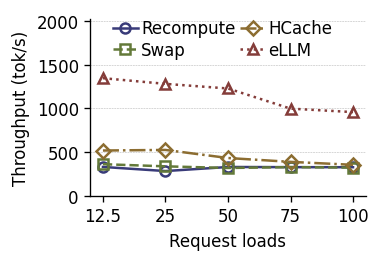

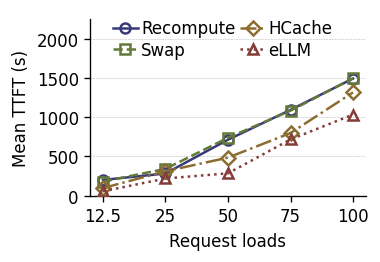

In [4]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
num_promts = 3024
data_name = 'sharegpt'
num_prompts = [787, 1553, 3024, 4541, 6069]
x_labels = [12.5, 25, 50, 75, 100]
avg_prompts = [item/60 for item in num_prompts]
print(f"avg_prompts: {avg_prompts}")
model_name = 'meta-llama_Llama-2-13b-chat-hf'
current_date = '2025-04-27'  
file_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}_13b.csv'
print(f"file_path: {file_path}")
metrics = ['avg_output_throughput', 'avg_mean_ttft',  'avg_mean_tpot']
plot_various_loads(file_path, 'avg_output_throughput', 'Throughput (tok/s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)
plot_various_loads(file_path, 'avg_mean_ttft', 'Mean TTFT (s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)

file_path: /root/workspace/vllm-dynamic/scripts/dataset/e2e/e2e_results_various_rates_sharegpt_2025-04-29_70b_camera_ready.csv
meta-llama_Llama-2-70b-chat-hf 787 vllm-recompute 421.5083333333334 improvement: 1.74
meta-llama_Llama-2-70b-chat-hf 787 vllm-swap 427.1333333333334 improvement: 1.72
meta-llama_Llama-2-70b-chat-hf 787 hcache 554.19 improvement: 1.32
meta-llama_Llama-2-70b-chat-hf 787 ellm 732.75 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 1553 vllm-recompute 438.78 improvement: 1.75
meta-llama_Llama-2-70b-chat-hf 1553 vllm-swap 423.29 improvement: 1.82
meta-llama_Llama-2-70b-chat-hf 1553 hcache 559.31 improvement: 1.38
meta-llama_Llama-2-70b-chat-hf 1553 ellm 769.6160000000001 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 3024 vllm-recompute 452.814 improvement: 1.99
meta-llama_Llama-2-70b-chat-hf 3024 vllm-swap 450.958 improvement: 2.00
meta-llama_Llama-2-70b-chat-hf 3024 hcache 563.46 improvement: 1.60
meta-llama_Llama-2-70b-chat-hf 3024 ellm 901.281111111111 improve

/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_480729/3725513870.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_df[metric] = system_df[metric] / 1000
/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


meta-llama_Llama-2-70b-chat-hf 787 vllm-recompute 73777.925 improvement: 2.28
meta-llama_Llama-2-70b-chat-hf 787 vllm-swap 72812.84999999999 improvement: 2.25
meta-llama_Llama-2-70b-chat-hf 787 hcache 57071.92 improvement: 1.77
meta-llama_Llama-2-70b-chat-hf 787 ellm 32296.115 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 1553 vllm-recompute 194545.47 improvement: 1.80
meta-llama_Llama-2-70b-chat-hf 1553 vllm-swap 192065.092 improvement: 1.77
meta-llama_Llama-2-70b-chat-hf 1553 hcache 143819.7 improvement: 1.33
meta-llama_Llama-2-70b-chat-hf 1553 ellm 108258.98399999998 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 3024 vllm-recompute 452655.5280000001 improvement: 1.62
meta-llama_Llama-2-70b-chat-hf 3024 vllm-swap 448741.4360000001 improvement: 1.61
meta-llama_Llama-2-70b-chat-hf 3024 hcache 337101.64 improvement: 1.21
meta-llama_Llama-2-70b-chat-hf 3024 ellm 278821.4655555556 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 4541 vllm-recompute 850702.2366666667 improvement: 1.8

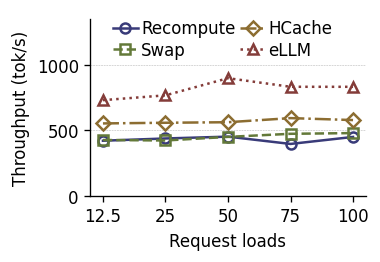

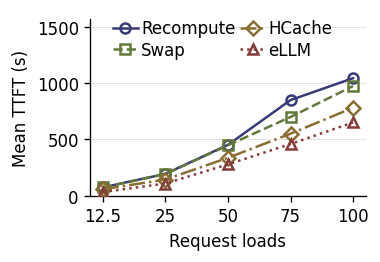

In [5]:
model_name = 'meta-llama_Llama-2-70b-chat-hf'
current_date = '2025-04-29'  
file_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}_70b_camera_ready.csv'
print(f"file_path: {file_path}")
metrics = ['avg_output_throughput', 'avg_mean_ttft',  'avg_mean_tpot']
plot_various_loads(file_path, 'avg_output_throughput', 'Throughput (tok/s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)
plot_various_loads(file_path, 'avg_mean_ttft', 'Mean TTFT (s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)

avg_prompts: [3.066666666666667, 5.533333333333333, 7.733333333333333, 10.6, 13.116666666666667]
meta-llama_Llama-2-13b-chat-hf 184 vllm-recompute 285.40000000000003 improvement: 2.74
meta-llama_Llama-2-13b-chat-hf 184 vllm-swap 257.66 improvement: 3.03
meta-llama_Llama-2-13b-chat-hf 184 hcache 484.64 improvement: 1.61
meta-llama_Llama-2-13b-chat-hf 184 ellm 781.2216666666667 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 332 vllm-recompute 272.53 improvement: 3.02
meta-llama_Llama-2-13b-chat-hf 332 vllm-swap 314.01 improvement: 2.62
meta-llama_Llama-2-13b-chat-hf 332 hcache 491.91 improvement: 1.67
meta-llama_Llama-2-13b-chat-hf 332 ellm 822.1899999999999 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 464 vllm-recompute 295.18 improvement: 3.03
meta-llama_Llama-2-13b-chat-hf 464 vllm-swap 311.43333333333334 improvement: 2.87
meta-llama_Llama-2-13b-chat-hf 464 hcache 448.58 improvement: 1.99
meta-llama_Llama-2-13b-chat-hf 464 ellm 893.4333333333333 improvement: 1.00
meta-llama_Llam

/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_480729/3725513870.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_df[metric] = system_df[metric] / 1000
/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


meta-llama_Llama-2-13b-chat-hf 184 vllm-recompute 258070.80666666664 improvement: 1.76
meta-llama_Llama-2-13b-chat-hf 184 vllm-swap 250703.362 improvement: 1.71
meta-llama_Llama-2-13b-chat-hf 184 hcache 201196.72 improvement: 1.37
meta-llama_Llama-2-13b-chat-hf 184 ellm 146513.1383333333 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 332 vllm-recompute 600282.63 improvement: 2.71
meta-llama_Llama-2-13b-chat-hf 332 vllm-swap 468571.9566666666 improvement: 2.12
meta-llama_Llama-2-13b-chat-hf 332 hcache 446472.41 improvement: 2.02
meta-llama_Llama-2-13b-chat-hf 332 ellm 221443.73666666663 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 464 vllm-recompute 718600.3166666668 improvement: 2.43
meta-llama_Llama-2-13b-chat-hf 464 vllm-swap 680247.6366666666 improvement: 2.30
meta-llama_Llama-2-13b-chat-hf 464 hcache 503773.62 improvement: 1.70
meta-llama_Llama-2-13b-chat-hf 464 ellm 295974.9766666666 improvement: 1.00
meta-llama_Llama-2-13b-chat-hf 636 vllm-recompute 1017672.4533333333 impro

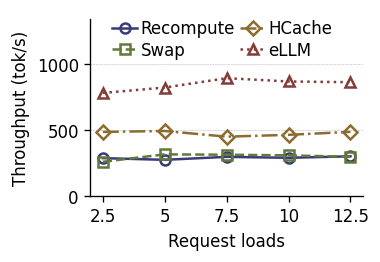

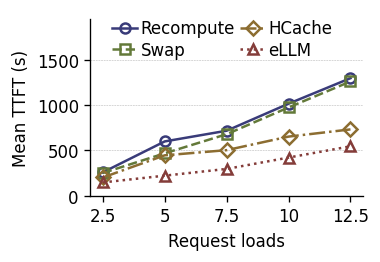

In [6]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
data_name = 'paper_assistant'
num_prompts = [184, 332, 464, 636, 787]
x_labels = [2.5, 5, 7.5, 10, 12.5]
avg_prompts = [item/60 for item in num_prompts]
print(f"avg_prompts: {avg_prompts}")
now = datetime.datetime.now()
current_date = '2025-04-28'
model_name = 'meta-llama_Llama-2-13b-chat-hf'
file_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}_13b.csv'
plot_various_loads(file_path, 'avg_output_throughput', 'Throughput (tok/s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)
plot_various_loads(file_path, 'avg_mean_ttft', 'Mean TTFT (s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)

meta-llama_Llama-2-70b-chat-hf 184 vllm-recompute 215.58 improvement: 1.85
meta-llama_Llama-2-70b-chat-hf 184 vllm-swap 167.80999999999997 improvement: 2.38
meta-llama_Llama-2-70b-chat-hf 184 hcache 261.562 improvement: 1.53
meta-llama_Llama-2-70b-chat-hf 184 ellm 399.218 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 332 vllm-recompute 220.87 improvement: 1.98
meta-llama_Llama-2-70b-chat-hf 332 vllm-swap 206.21166666666667 improvement: 2.12
meta-llama_Llama-2-70b-chat-hf 332 hcache 330.92 improvement: 1.32
meta-llama_Llama-2-70b-chat-hf 332 ellm 436.66333333333336 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 464 vllm-recompute 215.53 improvement: 2.15
meta-llama_Llama-2-70b-chat-hf 464 vllm-swap 213.235 improvement: 2.17
meta-llama_Llama-2-70b-chat-hf 464 hcache 314.26 improvement: 1.47
meta-llama_Llama-2-70b-chat-hf 464 ellm 462.415 improvement: 1.00
meta-llama_Llama-2-70b-chat-hf 636 vllm-recompute 219.49 improvement: 2.05
meta-llama_Llama-2-70b-chat-hf 636 vllm-swap 236.08 im

/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_480729/3725513870.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_df[metric] = system_df[metric] / 1000
/tmp/ipykernel_480729/3725513870.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


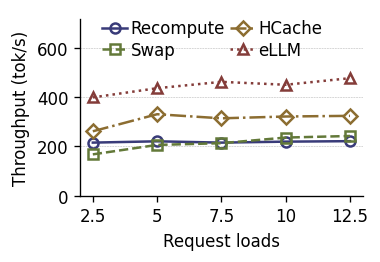

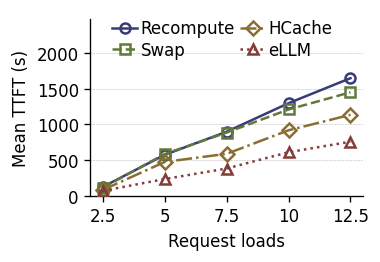

In [7]:
current_date = '2025-04-29'
model_name = 'meta-llama_Llama-2-70b-chat-hf'
file_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}_70b_camera_ready.csv'
plot_various_loads(file_path, 'avg_output_throughput', 'Throughput (tok/s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)
plot_various_loads(file_path, 'avg_mean_ttft', 'Mean TTFT (s)', x_labels, model_name, data_name, system_names, system_labels, num_prompts)